<a href="https://colab.research.google.com/github/eduardozurek/ia/blob/main/_007_aprendizaje_supervisado/_006_04_KNN_GridSearch_Multimetricas_Ponderadas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KNN multiclase: GridSearch con indicadores ponderados
Se buscan valores de **K entre 5 y 200, en pasos de 5**, conservando los datos sintéticos originales, distancia euclidiana y votos uniformes.

El mejor K es el que maximiza una **puntuación compuesta de validación cruzada**. Los pesos representan una elección de objetivos, no una combinación universalmente óptima. Se pueden cambiar en una única celda.

Correcciones respecto al original: separación estratificada antes de ajustar la escala; GridSearch solo sobre entrenamiento; escalador dentro de un Pipeline; evaluación del modelo que GridSearch selecciona; regiones multiclase mediante `predict()`, sin umbral 0.5.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             cohen_kappa_score, log_loss,
                             classification_report, ConfusionMatrixDisplay)
from IPython.display import display

X, y = make_blobs(n_samples=[500, 500, 500, 500], n_features=2,
                  centers=[[1.50, 35], [1.75, 70], [1.50, 50], [1.75, 50]],
                  cluster_std=[[.1, 10], [.1, 10], [.1, 10], [.1, 10]],
                  random_state=1970)
y = y + 1
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.33, random_state=1970, stratify=y)
print(f'Entrenamiento: {len(y_train)}; prueba reservada: {len(y_test)}')

Entrenamiento: 1340; prueba reservada: 660


## 1. Pesos y transformaciones
Para cada partición se calcula $S=\sum_j w_j u_j$, con $\sum_j w_j=1$. Todos los componentes $u_j$ se orientan a **mayor es mejor** y están entre 0 y 1.

| Indicador | Transformación a utilidad $u_j$ | Peso inicial |
|---|---|---:|
| Accuracy | Accuracy | 20 % |
| F1 macro | F1 macro | 20 % |
| ROC-AUC macro OvR | AUC | 15 % |
| Kappa sin ponderación ordinal | $(\kappa+1)/2$ | 10 % |
| Log loss | $\exp(-L)$ | 20 % |
| Brier multiclase | $1-B/2$ | 15 % |

Brier se define como $B=\frac{1}{N}\sum_i\sum_c(p_{ic}-1[y_i=c])^2$, con rango 0 a 2. $\exp(-L)$ equivale a la media geométrica de las probabilidades asignadas a la clase real (con el recorte numérico de Log loss).

Estas transformaciones usan escalas fijas y no dependen del mejor o peor candidato de la rejilla. No hacen que los indicadores sean equivalentes: los pesos y transformaciones siguen siendo decisiones de diseño. Accuracy y Kappa pueden ser redundantes, especialmente con clases balanceadas; asigne peso cero a un indicador si desea excluirlo. Fije pesos sin consultar los resultados de prueba.

In [2]:
PESOS = {
    'accuracy': 0.20,
    'f1_macro': 0.20,
    'auc_ovr': 0.15,
    'kappa': 0.10,
    'log_loss': 0.20,
    'brier': 0.15,
}
VALORES_K = np.arange(5, 201, 5)
if not all(np.isfinite(w) and w >= 0 for w in PESOS.values()):
    raise ValueError('Los pesos deben ser finitos y no negativos.')
if not np.isclose(sum(PESOS.values()), 1):
    raise ValueError('Los pesos deben sumar 1.')
display(pd.Series(PESOS, name='Peso').to_frame())

,Peso
accuracy,0.20
f1_macro,0.20
auc_ovr,0.15
kappa,0.10
log_loss,0.20
brier,0.15


## 2. Evaluador con varios indicadores
El evaluador devuelve los indicadores individuales y la puntuación ponderada en una sola llamada. Log loss y Brier se devuelven negativos para respetar la convención de scikit-learn (mayor puntuación es mejor); las tablas recuperan sus valores positivos.

La puntuación final es el promedio de $S$ entre las cinco particiones. Las transformaciones se aplican **antes** de promediar: en particular, la media de $\exp(-L)$ no es $\exp(-\text{media}(L))$.

In [3]:
def evaluar_metricas(modelo, datos, etiquetas):
    probabilidades = modelo.predict_proba(datos)
    clases = modelo.classes_
    pred = clases[np.argmax(probabilidades, axis=1)]
    onehot = (np.asarray(etiquetas)[:, None] == clases[None, :]).astype(float)
    return {
        'accuracy': accuracy_score(etiquetas, pred),
        'f1_macro': f1_score(etiquetas, pred, average='macro', zero_division=0),
        'auc_ovr': roc_auc_score(etiquetas, probabilidades, multi_class='ovr',
                                 average='macro', labels=clases),
        'kappa': cohen_kappa_score(etiquetas, pred),
        'log_loss': log_loss(etiquetas, probabilidades, labels=clases),
        'brier': np.mean(np.sum((probabilidades-onehot)**2, axis=1)),
    }

def utilidades(metricas):
    return {
        'accuracy': metricas['accuracy'],
        'f1_macro': metricas['f1_macro'],
        'auc_ovr': metricas['auc_ovr'],
        'kappa': (metricas['kappa']+1)/2,
        'log_loss': np.exp(-metricas['log_loss']),
        'brier': 1-metricas['brier']/2,
    }

def evaluador_ponderado(modelo, datos, etiquetas):
    m = evaluar_metricas(modelo, datos, etiquetas)
    u = utilidades(m)
    salida = {nombre: (-valor if nombre in ['log_loss', 'brier'] else valor)
              for nombre, valor in m.items()}
    salida.update({f'utilidad_{nombre}': valor for nombre, valor in u.items()})
    salida['ponderado'] = sum(PESOS[nombre]*u[nombre] for nombre in PESOS)
    return salida

## 3. GridSearchCV
`refit='ponderado'` selecciona por puntuación compuesta y vuelve a ajustar el Pipeline ganador sobre todo el entrenamiento. Las mismas particiones sirven para todos los K. En empates exactos, se toma el primer candidato, que aquí es el menor K.

In [4]:
cv = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=1970)
          .split(X_train, y_train))
if max(VALORES_K) > min(len(it) for it, _ in cv):
    raise ValueError('El K máximo supera el tamaño de entrenamiento de una partición.')
pipeline = Pipeline([
    ('escala', StandardScaler()),
    ('knn', KNeighborsClassifier(weights='uniform', algorithm='brute',
                                 metric='minkowski', p=2))
])
search = GridSearchCV(
    pipeline, {'knn__n_neighbors': VALORES_K.tolist()},
    scoring=evaluador_ponderado, refit='ponderado',
    cv=cv, n_jobs=1, error_score='raise', return_train_score=False)
search.fit(X_train, y_train)
mejor_modelo = search.best_estimator_
r = search.cv_results_
indice_ponderado = search.best_index_
indice_accuracy = int(np.argmax(r['mean_test_accuracy']))
k_ponderado = search.best_params_['knn__n_neighbors']
k_accuracy = r['params'][indice_accuracy]['knn__n_neighbors']
print(f'Mejor K por puntuación ponderada: {k_ponderado}')
print(f'Puntuación ponderada de validación: {search.best_score_:.6f}')
print(f'Mejor K usando solo accuracy: {k_accuracy}')

# Tabla completa en orden de puntuación compuesta.
tabla = pd.DataFrame({'K': [p['knn__n_neighbors'] for p in r['params']]})
for nombre in PESOS:
    signo = -1 if nombre in ['log_loss', 'brier'] else 1
    tabla[nombre] = signo*r[f'mean_test_{nombre}']
tabla['ponderado'] = r['mean_test_ponderado']
tabla['desv_ponderado'] = r['std_test_ponderado']
display(tabla.sort_values(['ponderado', 'K'], ascending=[False, True]))

# Desglose exacto del promedio compuesto para el K ganador.
desglose = pd.DataFrame({
    'Indicador': list(PESOS),
    'Peso': list(PESOS.values()),
    'Utilidad media CV': [r[f'mean_test_utilidad_{nombre}'][indice_ponderado]
                         for nombre in PESOS]
})
desglose['Aporte'] = desglose['Peso']*desglose['Utilidad media CV']
display(desglose)
print(f"Suma de aportes: {desglose['Aporte'].sum():.6f}")
assert np.isclose(desglose['Aporte'].sum(), search.best_score_)

Mejor K por puntuación ponderada: 130
Puntuación ponderada de validación: 0.743366
Mejor K usando solo accuracy: 165


,K,accuracy,f1_macro,auc_ovr,kappa,log_loss,brier,ponderado,desv_ponderado
25,130,0.737313,0.737564,0.927230,0.649751,0.646037,0.373932,0.743366,0.012612
32,165,0.738060,0.738433,0.926463,0.650746,0.656755,0.379731,0.742065,0.010879
26,135,0.734328,0.734484,0.926842,0.645771,0.648037,0.374918,0.741611,0.012594
27,140,0.734328,0.734545,0.926951,0.645771,0.648523,0.375115,0.741573,0.012784
30,155,0.735075,0.735297,0.926977,0.646766,0.651986,0.377177,0.741404,0.012164
29,150,0.734328,0.734573,0.927140,0.645771,0.650013,0.376352,0.741351,0.011386
33,170,0.736567,0.737000,0.926528,0.648756,0.658531,0.380525,0.741147,0.010428
28,145,0.732836,0.733030,0.926888,0.643781,0.650154,0.376160,0.740609,0.011929
31,160,0.734328,0.734639,0.926530,0.645771,0.655081,0.378588,0.740578,0.011398
24,125,0.735821,0.736011,0.927020,0.647761,0.668289,0.373876,0.740486,0.014773


,Indicador,Peso,Utilidad media CV,Aporte
0,accuracy,0.20,0.737313,0.147463
1,f1_macro,0.20,0.737564,0.147513
2,auc_ovr,0.15,0.927230,0.139084
3,kappa,0.10,0.824876,0.082488
4,log_loss,0.20,0.524317,0.104863
5,brier,0.15,0.813034,0.121955


Suma de aportes: 0.743366


## 4. Gráficas de selección
Las bandas representan ± una desviación estándar entre particiones (no intervalos de confianza). Las líneas verticales identifican el ganador ponderado y el ganador por accuracy. El promedio compuesto puede mejorar a costa de alguno de sus componentes.

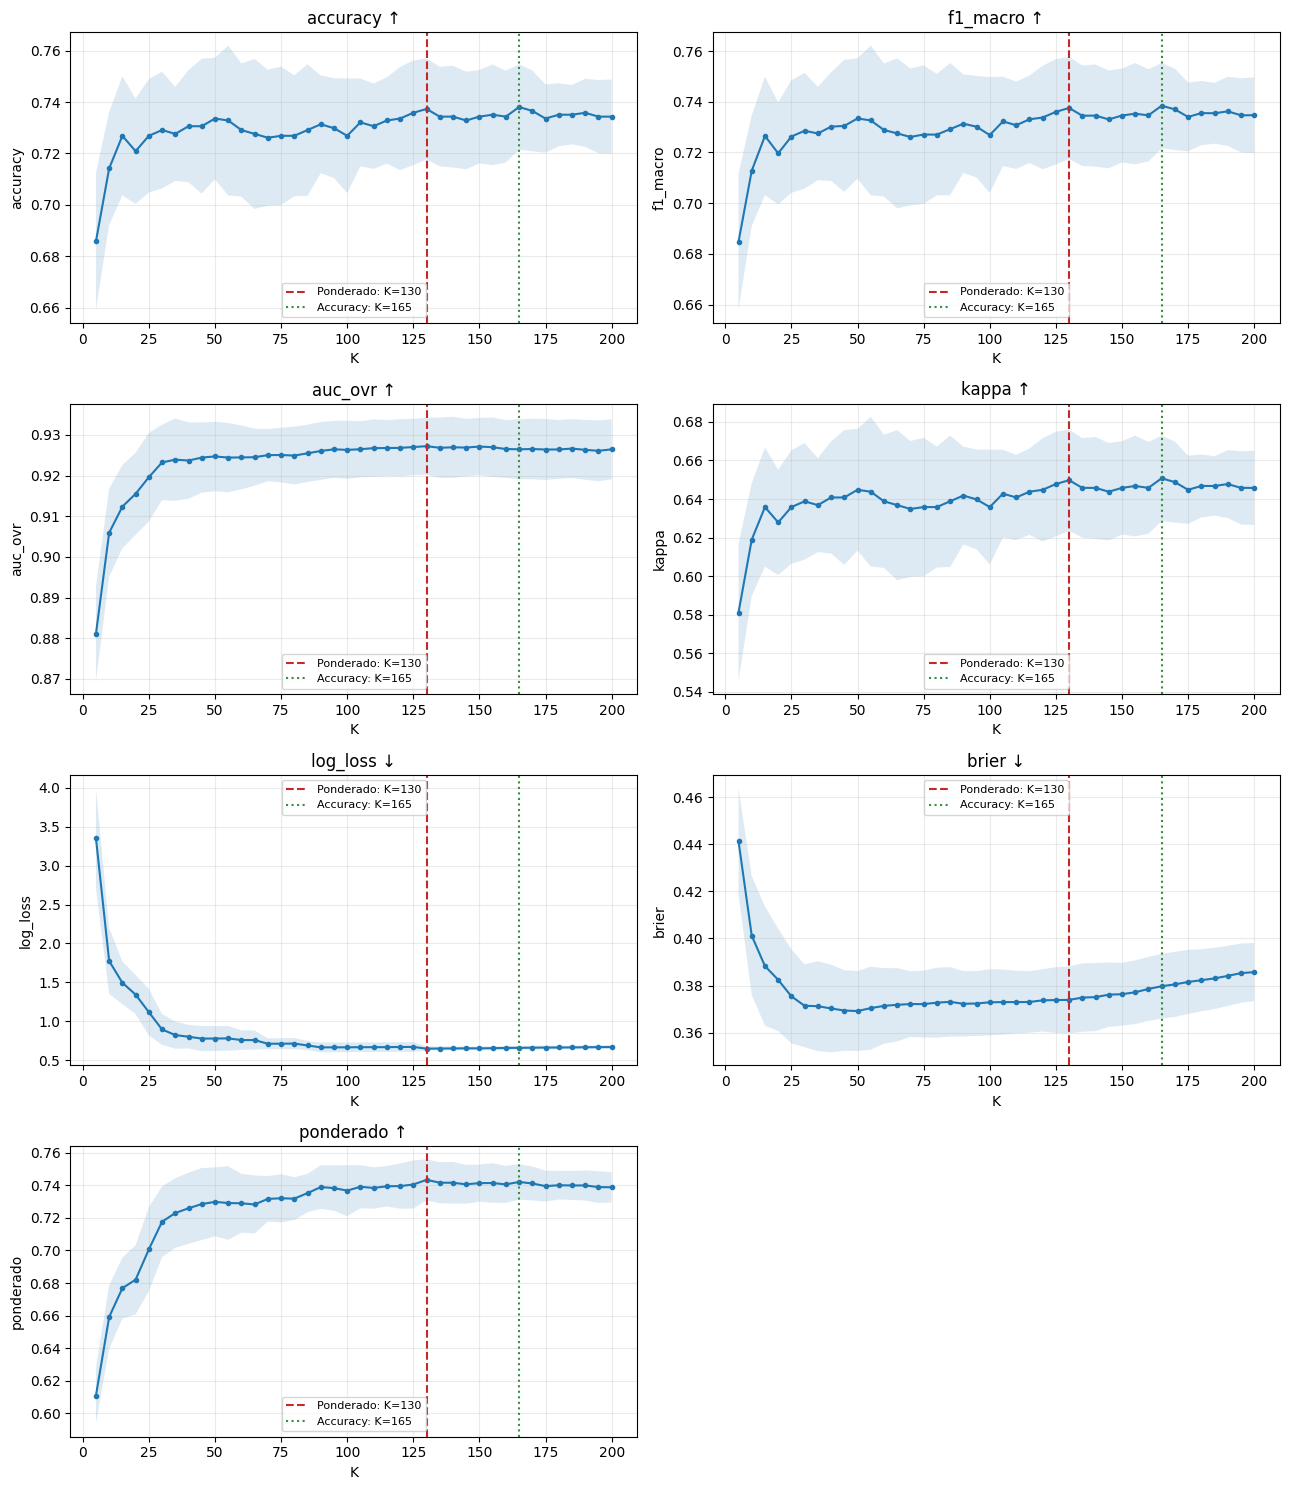

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(13, 15), sharex=True)
for ax, nombre in zip(axes.ravel(), list(PESOS)+['ponderado']):
    signo = -1 if nombre in ['log_loss', 'brier'] else 1
    media = signo*r[f'mean_test_{nombre}']
    sd = r[f'std_test_{nombre}']
    ax.plot(VALORES_K, media, 'o-', markersize=3)
    ax.fill_between(VALORES_K, media-sd, media+sd, alpha=.15)
    ax.axvline(k_ponderado, color='#c62828', linestyle='--', label=f'Ponderado: K={k_ponderado}')
    ax.axvline(k_accuracy, color='#388e3c', linestyle=':', label=f'Accuracy: K={k_accuracy}')
    ax.set(title=nombre + (' ↓' if signo == -1 else ' ↑'), xlabel='K', ylabel=nombre)
    ax.tick_params(labelbottom=True)
    ax.ticklabel_format(axis='y', style='plain', useOffset=False)
    ax.grid(alpha=.25)
    ax.legend(fontsize=8)
axes.ravel()[-1].axis('off')
fig.tight_layout()
plt.show()

## 5. Evaluación final del modelo seleccionado
El conjunto de prueba se usa aquí una vez fijada la selección. No cambie pesos o K basándose en esta evaluación: dejaría de ser una prueba independiente.

,Prueba final
accuracy,0.721212
f1_macro,0.721808
auc_ovr,0.925690
kappa,0.628283
log_loss,0.641485
brier,0.372670


              precision    recall  f1-score   support

           1     0.7108    0.7152    0.7130       165
           2     0.7974    0.7394    0.7673       165
           3     0.6608    0.6848    0.6726       165
           4     0.7235    0.7455    0.7343       165

    accuracy                         0.7212       660
   macro avg     0.7231    0.7212    0.7218       660
weighted avg     0.7231    0.7212    0.7218       660



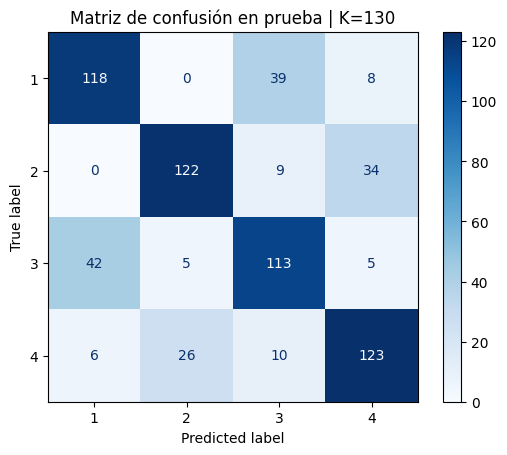

In [6]:
metricas_prueba = evaluar_metricas(mejor_modelo, X_test, y_test)
display(pd.Series(metricas_prueba, name='Prueba final').to_frame())
y_predicho = mejor_modelo.predict(X_test)
print(classification_report(y_test, y_predicho, digits=4, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, y_predicho, cmap='Blues')
plt.title(f'Matriz de confusión en prueba | K={k_ponderado}')
plt.show()

## 6. Regiones del modelo seleccionado
El Pipeline recibe estatura y peso en sus unidades originales y aplica internamente el escalador. Se muestran los ejemplos de entrenamiento y se usa la clase de mayor probabilidad; no se aplica un umbral de 0.5 a cada categoría.

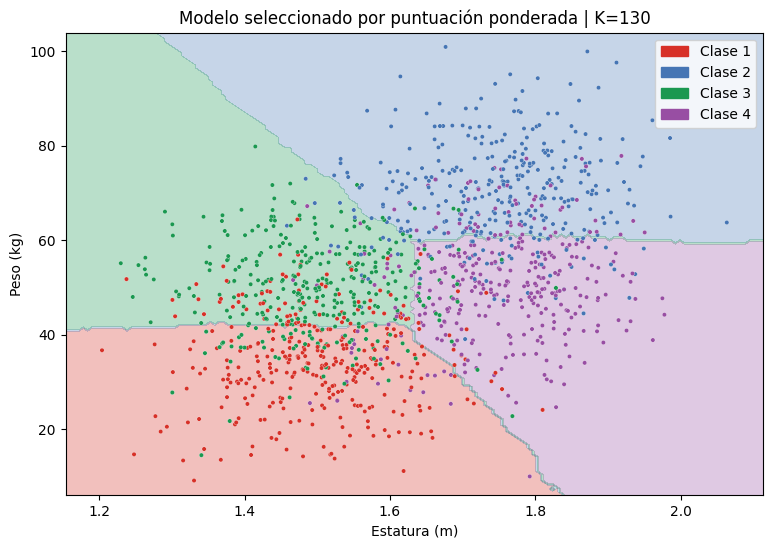

In [7]:
colores = ['#d73027', '#4575b4', '#1a9850', '#984ea3']
cm = ListedColormap(colores)
gx = np.linspace(X_train[:, 0].min()-.05, X_train[:, 0].max()+.05, 160)
gy = np.linspace(X_train[:, 1].min()-3, X_train[:, 1].max()+3, 160)
mx, my = np.meshgrid(gx, gy)
z = mejor_modelo.predict(np.c_[mx.ravel(), my.ravel()]).reshape(mx.shape)
fig, ax = plt.subplots(figsize=(9, 6))
ax.contourf(mx, my, z, levels=np.arange(.5, 5, 1), cmap=cm, alpha=.3)
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm,
           vmin=1, vmax=4, s=10, edgecolors='white', linewidths=.2)
ax.set(xlabel='Estatura (m)', ylabel='Peso (kg)',
       title=f'Modelo seleccionado por puntuación ponderada | K={k_ponderado}')
ax.legend(handles=[Patch(color=color, label=f'Clase {i}')
                   for i, color in enumerate(colores, 1)])
plt.show()

## Para experimentar con los pesos
Modifique `PESOS` y vuelva a ejecutar desde esa celda hasta las gráficas de validación. Mantenga fija la prueba mientras define el criterio. También puede modificar `VALORES_K` para refinar una zona prometedora. El K seleccionado es el mejor **entre los candidatos y para los pesos, transformaciones y particiones elegidos**, no un óptimo universal. La puntuación de validación del ganador puede ser optimista por la propia selección; la prueba final proporciona una evaluación separada.